## Data preparation

Plate reader data is loaded using pr.load_platereader_data, which parses the raw instrument output and merges the platemap to annotate each well with its construct identity.

In [ ]:
!pip install nucleus-cdk==0.5.0rc2 | tail -n2

In [1]:
from cdk.analysis.cytosol import platereader as pr
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from matplotlib.patches import Patch


warnings.filterwarnings('ignore')
pr.plot_setup()

In [2]:
# Load background-subtracted data
mango_data = pd.read_csv("../20251030_Aptamer_test_Mango_mScarlet/20251030_MangoTO1_mScarlet_data_background_sbtrk.csv")
mango_data["Time"] = pd.to_timedelta(mango_data["Time"])
mango_data["Experiment"] = "MangoIV"

broccoli_data = pd.read_csv("../20251027_Aptamer_test_Broccoli_mScarlet/20251027_Broccoli_mScarlet_data_Background_Sbtrkt.csv")
broccoli_data["Time"] = pd.to_timedelta(broccoli_data["Time"])
broccoli_data["Experiment"] = "Broccoli"

combined = pd.concat([mango_data, broccoli_data], ignore_index=True)
combined["Time (hours)"] = combined["Time"].dt.total_seconds() / 3600

print(f"MangoIV rows: {len(mango_data)}")
print(f"Broccoli rows: {len(broccoli_data)}")
print(f"Combined rows: {len(combined)}")
print(combined["Name"].unique())

# Kinetics
broccoli_aptamer_kinetics = pr.kinetic_analysis(
    broccoli_data[(broccoli_data["Name"] != "Negative") & (broccoli_data["Read"] == "GFP-Gext")],
    group_by=["Name", "Read", "Well"]
)
broccoli_mScarlet_kinetics = pr.kinetic_analysis(
    broccoli_data[(broccoli_data["Name"] != "Negative") & (broccoli_data["Read"] == "mScarlet")],
    group_by=["Name", "Read", "Well"]
)

# Extract lag times
broccoli_aptamer_lag = broccoli_aptamer_kinetics["Lag"]["Time"].dt.total_seconds() / 60
broccoli_mScarlet_lag = broccoli_mScarlet_kinetics["Lag"]["Time"].dt.total_seconds() / 60

# Means and stds
broccoli_aptamer_mean = broccoli_aptamer_lag.groupby("Name").mean()
broccoli_aptamer_std = broccoli_aptamer_lag.groupby("Name").std()
broccoli_mScarlet_mean = broccoli_mScarlet_lag.groupby("Name").mean()
broccoli_mScarlet_std = broccoli_mScarlet_lag.groupby("Name").std()

# SNR
steady_state = pr.find_steady_state(broccoli_data, group_by=["Name", "Read", "Well"])
ss_data = steady_state["Data_steadystate"]
noise = broccoli_data[broccoli_data["Name"] == "Negative"].groupby(["Time", "Read"])["Data"].std().groupby("Read").mean()
signal = ss_data.groupby(["Name", "Read"]).mean().drop("Negative", level="Name")
snr = signal / noise

# Signal stability
peak_signal = broccoli_data[broccoli_data["Name"] != "Negative"].groupby(["Name", "Read", "Well"])["Data"].max().groupby(["Name", "Read"]).mean()
end_signal = broccoli_data.groupby(["Name", "Read"]).apply(
    lambda g: g.loc[g["Time"].idxmax(), "Data"]
).groupby(["Name", "Read"]).mean()
stability = (end_signal / peak_signal).drop("Negative", level="Name")

# Translation initiation delay
delay_mean = broccoli_mScarlet_mean - broccoli_aptamer_mean
delay_std = (broccoli_mScarlet_std**2 + broccoli_aptamer_std**2)**0.5

# Build qc_df
broccoli_constructs = [
    "F30-2xBroccoli-mScarlet",
    "F30-2xBroccoli-RiboJ-mScarlet",
    "tdBroccoli-mScarlet",
    "tdBroccoli-RiboJ-mScarlet",
]
qc_df = pd.DataFrame({
    "Construct": [c.replace("-mScarlet", "") for c in broccoli_constructs],
    "Reporter": ["DFHBI-1T"] * len(broccoli_constructs),
    "SNR": [snr.loc[(c, "GFP-Gext")] for c in broccoli_constructs],
    "Lag CV (%)": [round(broccoli_aptamer_std.get(c, 0) / broccoli_aptamer_mean.get(c, 1) * 100, 1) for c in broccoli_constructs],
})

# Build delay_df
delay_df = pd.DataFrame({
    "Construct": delay_mean.index.str.replace("-mScarlet", ""),
    "Delay (minutes)": delay_mean.values,
    "Std": delay_std.values,
})

MangoIV rows: 1980
Broccoli rows: 2160
Combined rows: 4140
['Negative' 'F30MangoIV-mScarlet' 'F30MangoIV-RiboJ-mScarlet'
 'tMangoIV-mScarlet' 'tMangoIV-RiboJ-mScarlet' 'F30-2xBroccoli-mScarlet'
 'F30-2xBroccoli-RiboJ-mScarlet' 'tdBroccoli-mScarlet'
 'tdBroccoli-RiboJ-mScarlet']


Failed to solve for group ('Negative', 'GFP-Gext', 'D3'): An upper bound is less than the corresponding lower bound.


## Summary figure

A three-panel summary figure comparing transcription reporter quality across both aptamer systems and presenting the key biological result.

- **Panel 1 — Transcription reporter quality**: SNR plotted against lag CV (%) for all transcription reporter constructs on a log SNR scale. Each point represents a construct, coloured by reporter type (TO1-Biotin or DFHBI-1T). Points in the lower right represent optimal reporters with high SNR and low timing variability.

- **Panel 2 — Transcription reporter precision**: Lag CV (%) for all transcription reporter constructs grouped by reporter type. The dashed line indicates the 5% CV threshold below which timing measurements are considered sufficiently precise. Constructs are ordered by aptamer variant.

- **Panel 3 — Translation initiation delay**: The difference between the mScarlet lag time and the DFHBI-1T lag time for each Broccoli construct, representing the delay between detectable transcription onset and detectable translation onset. Error bars represent propagated standard deviation. Broccoli constructs only are shown as the MangoIV TO1-Biotin lag times are not sufficiently reliable for this comparison.

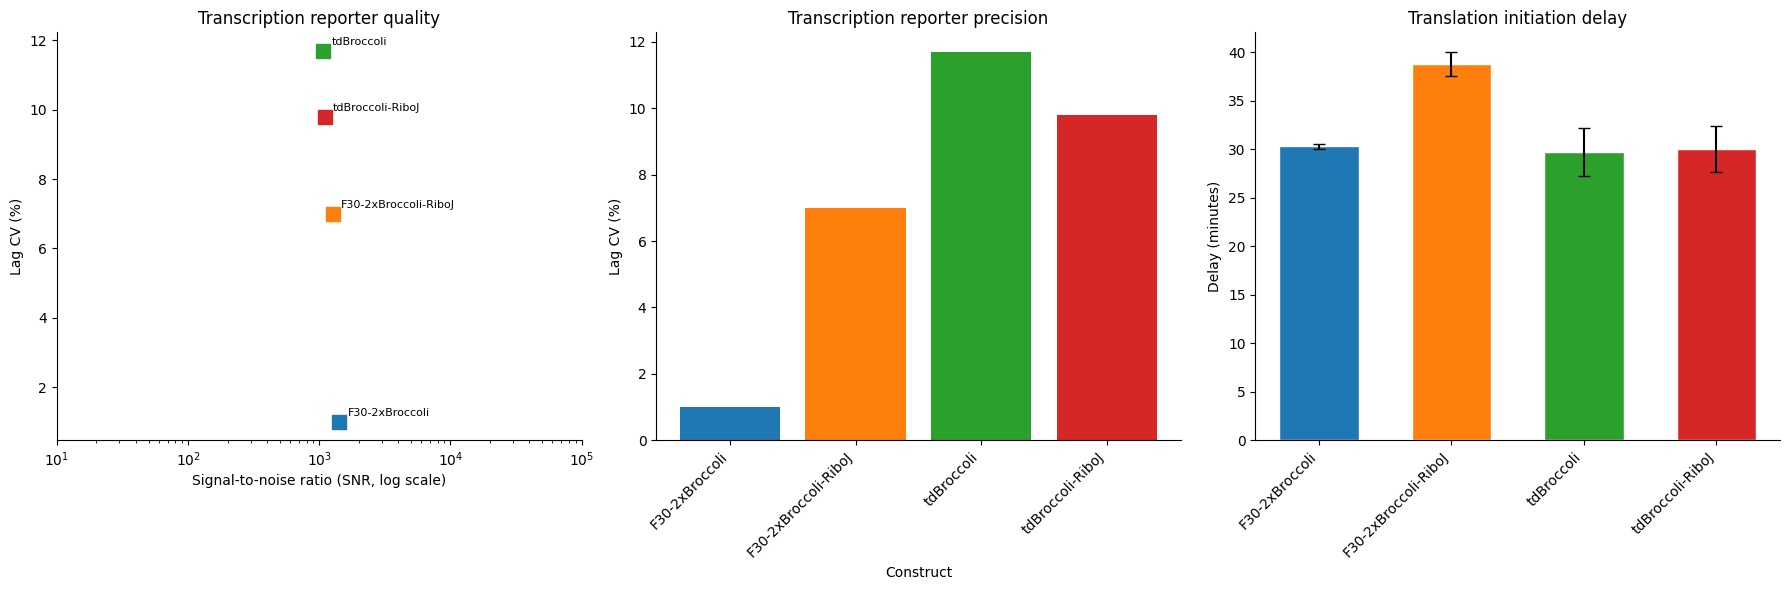

In [3]:
from matplotlib.patches import Patch

# Reorder constructs
construct_order_qc = [
    "F30-2xBroccoli", "F30-2xBroccoli-RiboJ",
    "tdBroccoli", "tdBroccoli-RiboJ"
]
qc_df["Construct"] = pd.Categorical(qc_df["Construct"], categories=construct_order_qc, ordered=True)
qc_df = qc_df.sort_values("Construct").reset_index(drop=True)

# Reorder delay_df
delay_df["Construct"] = pd.Categorical(delay_df["Construct"], categories=construct_order_qc, ordered=True)
delay_df = delay_df.sort_values("Construct").reset_index(drop=True)

# Colour scheme
broccoli_colours = {
    "F30-2xBroccoli": "tab:blue",
    "F30-2xBroccoli-RiboJ": "tab:orange",
    "tdBroccoli": "tab:green",
    "tdBroccoli-RiboJ": "tab:red",
}

# Three panel figure
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Panel 1 — SNR vs Lag CV scatter
for _, row in qc_df.iterrows():
    axes[0].scatter(row["SNR"], row["Lag CV (%)"],
                   color=broccoli_colours[row["Construct"]],
                   marker="s", s=100, zorder=3)
    axes[0].annotate(row["Construct"],
                    (row["SNR"], row["Lag CV (%)"]),
                    textcoords="offset points", xytext=(6, 4), fontsize=8)
axes[0].set_xscale("log")
axes[0].set_xlim(10, 100000)
axes[0].set_xlabel("Signal-to-noise ratio (SNR, log scale)")
axes[0].set_ylabel("Lag CV (%)")
axes[0].set_title("Transcription reporter quality")

# Panel 2 — Lag CV bar plot
axes[1].bar(range(len(qc_df)), qc_df["Lag CV (%)"],
            color=[broccoli_colours[c] for c in qc_df["Construct"]])
axes[1].set_xticks(range(len(qc_df)))
axes[1].set_xticklabels(qc_df["Construct"], rotation=45, ha="right")
axes[1].set_xlabel("Construct")
axes[1].set_ylabel("Lag CV (%)")
axes[1].set_title("Transcription reporter precision")

# Panel 3 — Translation initiation delay
for i, row in delay_df.iterrows():
    axes[2].bar(i, row["Delay (minutes)"],
                color=broccoli_colours.get(row["Construct"], "grey"),
                yerr=row["Std"], capsize=4, edgecolor="white", width=0.6)
axes[2].set_xticks(range(len(delay_df)))
axes[2].set_xticklabels(delay_df["Construct"], rotation=45, ha="right")
axes[2].set_ylabel("Delay (minutes)")
axes[2].set_title("Translation initiation delay")

sns.despine()
plt.tight_layout()
plt.savefig("./figures/Broccoli_mScarlet_summary_figure.png", dpi=600, bbox_inches="tight")
plt.show()

## Combined QC table

A unified QC table combining metrics from both the MangoIV and Broccoli experiments for all constructs and reporter combinations. Metrics are defined in the individual experiment notebooks. Note that tMangoIV TO1-Biotin lag times are not reported as no lag phase is detectable. † indicates a suspected construct label swap pending experimental confirmation.

In [4]:
# Build Broccoli QC table
rows = []

broccoli_constructs = {
    "F30-2xBroccoli-mScarlet": "GFP-Gext",
    "F30-2xBroccoli-RiboJ-mScarlet": "GFP-Gext",
    "tdBroccoli-mScarlet": "GFP-Gext",
    "tdBroccoli-RiboJ-mScarlet": "GFP-Gext",
}

for construct, aptamer_read in broccoli_constructs.items():
    clean_name = construct.replace("-mScarlet", "")

    # Aptamer row
    rows.append({
        "Construct": clean_name,
        "Reporter": "DFHBI-1T",
        "Lag detectable": "Yes",
        "SNR": round(snr.loc[(construct, aptamer_read)], 2),
        "R²": round(broccoli_aptamer_kinetics.loc[(construct, aptamer_read), "Fit"]["R^2"].mean(), 4),
        "Lag mean (min)": round(broccoli_aptamer_mean.get(construct, 0), 1),
        "Lag std (min)": round(broccoli_aptamer_std.get(construct, 0), 1),
        "Lag CV (%)": round(broccoli_aptamer_std.get(construct, 0) / broccoli_aptamer_mean.get(construct, 1) * 100, 1),
        "Signal stability": round(stability.loc[(construct, aptamer_read)], 2),
    })

    # mScarlet row
    rows.append({
        "Construct": clean_name,
        "Reporter": "mScarlet",
        "Lag detectable": "Yes",
        "SNR": round(snr.loc[(construct, "mScarlet")], 2),
        "R²": round(broccoli_mScarlet_kinetics.loc[(construct, "mScarlet"), "Fit"]["R^2"].mean(), 4),
        "Lag mean (min)": round(broccoli_mScarlet_mean.get(construct, 0), 1),
        "Lag std (min)": round(broccoli_mScarlet_std.get(construct, 0), 1),
        "Lag CV (%)": round(broccoli_mScarlet_std.get(construct, 0) / broccoli_mScarlet_mean.get(construct, 1) * 100, 1),
        "Signal stability": round(stability.loc[(construct, "mScarlet")], 2),
    })

broccoli_qc_table = pd.DataFrame(rows)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
print(broccoli_qc_table)

              Construct  Reporter Lag detectable      SNR   R²  Lag mean (min)  Lag std (min)  Lag CV (%)  Signal stability
0        F30-2xBroccoli  DFHBI-1T            Yes  1420.15 0.99           22.90           0.20        1.00              0.93
1        F30-2xBroccoli  mScarlet            Yes 41160.59 1.00           53.20           0.10        0.20              0.98
2  F30-2xBroccoli-RiboJ  DFHBI-1T            Yes  1268.23 1.00           15.70           1.10        7.00              1.00
3  F30-2xBroccoli-RiboJ  mScarlet            Yes 49371.80 1.00           54.50           0.60        1.10              0.99
4            tdBroccoli  DFHBI-1T            Yes  1067.99 0.99           20.80           2.40       11.70              0.86
5            tdBroccoli  mScarlet            Yes 40238.43 1.00           50.50           0.60        1.10              0.98
6      tdBroccoli-RiboJ  DFHBI-1T            Yes  1103.82 0.99           23.40           2.30        9.80              0.88
7      t